The intent of this work is to make a AI systems able to predict students that are prone to dropout Highscholl. 
However, highschool datasets are really hard to find/ have access to in Brazil, so we are starting this project with 2 datasets that  simulates a realistic academic environment from Kaggle. Further more, I will use a dataset that's already being used on another study on my university. <br>The data bases links are:
*  https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset
*  https://www.kaggle.com/datasets/gabrielmarcano/evaso-escolar-cdac-150-linhas/data

In [91]:
# from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import parallel_coordinates
import seaborn as sns
# from sklearn.tree import DecisionTreeClassifier, plot_tree
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# from sklearn.naive_bayes import GaussianNB
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import silhouette_score
import numpy as np

In [65]:
evasaoCDAC = pd.read_csv('data\dataset_evasao_cdac.csv')
studentDropout = pd.read_csv('data\student_dropout_dataset_v3.csv')

evasaoCDAC contains a dataset wich have 150 registers and the features are:
-  Student ID
-  Name
-  Nota Média 
-  Frequência (%) → Percentual de presença nas aulas.
-  Atividades Extracurriculares → Indica se o aluno participa de atividades fora do horário regular.

-  Absenteísmo → Número ou nível de faltas registradas.

-  Programa de Apoio → Indica se o aluno recebe suporte institucional (bolsas, reforço escolar etc.).

-  Participação nas Aulas (%) → Percentual de engajamento e participação efetiva nas aulas.

-  Evasão → Variável-alvo que indica se o aluno abandonou ou não a escola (Sim/Não).

In [66]:
evasaoCDAC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID do Aluno                   150 non-null    int64  
 1   Nome                          150 non-null    object 
 2   Nota Media                    150 non-null    float64
 3   Frequencia (%)                150 non-null    int64  
 4   Atividades Extracurriculares  150 non-null    object 
 5   Absenteismo                   150 non-null    int64  
 6   Programa de Apoio             150 non-null    object 
 7   Participacao nas Aulas (%)    150 non-null    int64  
 8   Evasao                        150 non-null    object 
dtypes: float64(1), int64(4), object(4)
memory usage: 10.7+ KB


studentDropout has the features:
-  Student_ID             
-   Age                    
-   Gender                 
-   Family_Income          
-   Internet_Access        
-   Study_Hours_per_Day    
-   Attendance_Rate        
-   Assignment_Delay_Days  
-   Travel_Time_Minutes    
-   Part_Time_Job           
-  Scholarship            
-  Stress_Index           
-  GPA                    
-  Semester_GPA          
-  CGPA                   
-  Semester               
-  Department              
-  Parental_Education      
-  Dropout

However, Family_Income, Study_Hours_per_Day, Stress_Index and Parental education has aproximately 500 missing registers

In [67]:
studentDropout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

First things first, we have to explore how the data works itself, so let's make some analysis!

In [68]:
studentDropout.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


Now we gotta __remove__ every null information! This leaves us with 9020 registers total.

In [74]:
studentDropout.dropna(inplace=True)

We will turn every pramether into a number.

In [69]:
print(studentDropout['Gender'].unique())
print(studentDropout['Internet_Access'].unique())
print(studentDropout['Part_Time_Job'].unique())
print(studentDropout['Scholarship'].unique())

['Male' 'Female']
['Yes' 'No']
['Yes' 'No']
['No' 'Yes']


In [70]:
studentDropout['Gender']= pd.to_numeric(studentDropout['Gender'].replace('Male','1').replace('Female', '0'), errors='coerce')
studentDropout['Internet_Access']= pd.to_numeric(studentDropout['Internet_Access'].replace('Yes','1').replace('No', '0'), errors='coerce')
studentDropout['Part_Time_Job']= pd.to_numeric(studentDropout['Part_Time_Job'].replace('Yes','1').replace('No', '0'), errors='coerce')
studentDropout['Scholarship']= pd.to_numeric(studentDropout['Scholarship'].replace('Yes','1').replace('No', '0'), errors='coerce') 
studentDropout['Semester']= pd.to_numeric(studentDropout['Semester'].str.replace('Year ',''), errors='coerce')

In [71]:
studentDropout['Internet_Access']= pd.to_numeric(studentDropout['Internet_Access'].replace('Yes','1').replace('No', '0'), errors='coerce')
studentDropout['Part_Time_Job']= pd.to_numeric(studentDropout['Part_Time_Job'].replace('Yes','1').replace('No', '0'), errors='coerce')
studentDropout['Scholarship']= pd.to_numeric(studentDropout['Scholarship'].replace('Yes','1').replace('No', '0'), errors='coerce') 
studentDropout['Semester']= pd.to_numeric(studentDropout['Semester'].str.replace('Year ',''), errors='coerce')

In [ ]:
studentDropout['Semester']= pd.to_numeric(studentDropout['Semester'].str.replace('Year ',''), errors='coerce')

[1 3 4 2]


Now, let's make and index for each of the departments and parental education

In [84]:
parentalEducationLevels = ['High School', 'Bachelor', 'Master', 'PhD']
studentDropout['Parental_Education'] = studentDropout['Parental_Education'].astype('category').cat.codes
departments = studentDropout['Department'].unique()
studentDropout['Department'] = studentDropout['Department'].astype('category').cat.codes

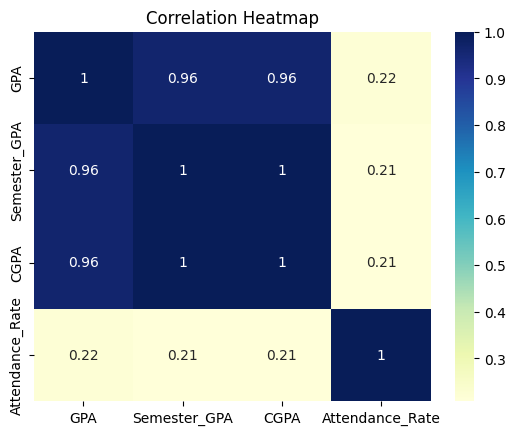

In [95]:
sns.heatmap(studentDropout[['GPA', 'Semester_GPA', 'CGPA', 'Attendance_Rate']].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

Looking at this heatmap we can see that only the GPA, Semester_GPA and CGPA explain the same thing. So we can choose only one of them. 
We don't need the student ID for this too, since its only an indentifier

In [96]:
studentDropout.drop(columns=['Student_ID', 'Semester_GPA', 'CGPA'], inplace=True)

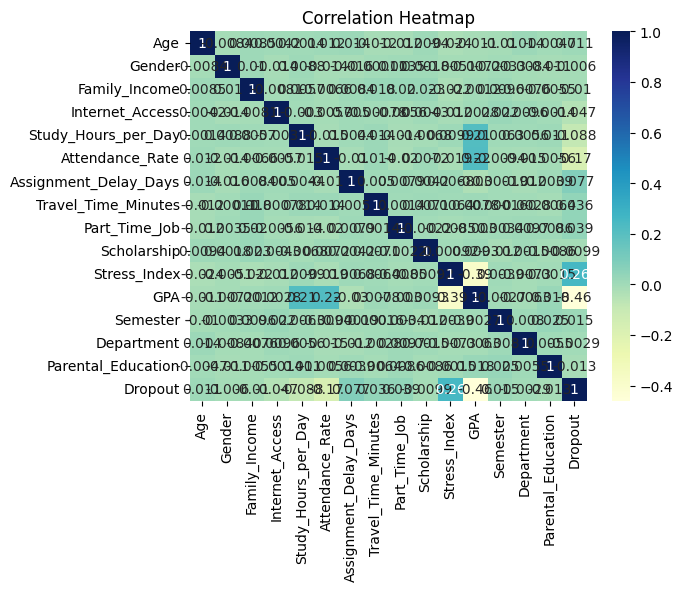

In [98]:
sns.heatmap(studentDropout.corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

# Coding
Now that we cleaned our database and treated any thing that could cause trouble, it's time we start coding